<a href="https://colab.research.google.com/github/kumisganteng/Data-Analytics-Projects/blob/energy_features_engineering/Energy_Consumption_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Ingestion

##1.1 Pemuatan Data

In [62]:
import pandas as pd

AEP_hourly_energy_dataset = "AEP_hourly.csv"
energy_data = pd.read_csv(AEP_hourly_energy_dataset)

##1.2 Inspeksi Awal

In [42]:
energy_data.shape

(121273, 2)

In [43]:
energy_data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [44]:
energy_data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [45]:
energy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [46]:
energy_data.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [47]:
energy_data.isnull().sum()

,0
Datetime,0
AEP_MW,0


In [48]:
energy_data.duplicated().sum()

np.int64(0)

###Cek Rentang Waktu

In [49]:
# cek rentang waktu data
print(energy_data['Datetime'].min())
print(energy_data['Datetime'].max())

# cek missing hours
energy_data['Datetime'] = pd.to_datetime(energy_data['Datetime'])
expected = pd.date_range(start=energy_data['Datetime'].min(),
                         end=energy_data['Datetime'].max(),
                         freq='h')
missing_hours = expected.difference(energy_data['Datetime'])
print(f"Missing hours: {len(missing_hours)}")

# cek duplikasi
print(f"Duplikasi: {energy_data.duplicated().sum()}")

# cek missing values
print(energy_data.isnull().sum())

2004-10-01 01:00:00
2018-08-03 00:00:00
Missing hours: 27
Duplikasi: 0
Datetime    0
AEP_MW      0
dtype: int64


#2. Data Cleaning

##2.1 Handle Missing Hours dan Duplikasi

In [56]:
print(energy_data.index.duplicated().sum())

0


In [57]:
# menghapus duplikasi di index
energy_data = energy_data[~energy_data.index.duplicated(keep='first')]

# mengcek setelah hapus duplikat
print(f"Duplikat setelah dibersihkan: {energy_data.index.duplicated().sum()}")
print(f"Shape: {energy_data.shape}")

# reindex
energy_data = energy_data.reindex(expected)
print(f"Missing values setelah reindex: {energy_data.isnull().sum().sum()}")

# interpolasi
energy_data['AEP_MW'] = energy_data['AEP_MW'].interpolate(method='time')
print(f"Missing values setelah interpolasi: {energy_data.isnull().sum().sum()}")
print(f"Shape akhir: {energy_data.shape}")

Duplikat setelah dibersihkan: 0
Shape: (121296, 2)
Missing values setelah reindex: 242592
Missing values setelah interpolasi: 242592
Shape akhir: (121296, 2)


### Insight yang didapat
Pada awalnya ketika belum set index untuk Datetime duplikasi masih 0,
Namun saat setelah saya lakukan set index untuk Datetime, ternyata ditemukan 4 duplikasi. Awalnya saya bingung karena waktu inspeksi awal
duplikasi 0, tapi ternyata ini bukan duplikasi biasa.

Setelah ditelusuri, ternyata ini terjadi karena **Daylight Saving Time (DST)**
yaitu sebuah kebijakan di Amerika dimana jam diputar mundur 1 jam di musim gugur.
Jadi ada jam yang sama muncul 2 kali di data, misalnya jam 02:00 bisa
tercatat dua kali dalam satu hari. Ini hal baru yang saya pelajari
dari dataset ini.

Penanganan yang dilakukan:
1. Hapus duplikat, keep baris pertama, buang yang kedua
2. Reindex dengan expected datetime (semua jam yang seharusnya ada)
3. Interpolasi untuk mengisi 27 jam yang kelewat

Hasilnya shape bertambah dari 121.269 ke 121.296 setelah
27 jam baru ditambahkan dan diisi dengan interpolasi.

##2.2 Validasi Range AEP_MW


In [58]:
# validasi range AEP_MW
print(f"Min AEP_MW: {energy_data['AEP_MW'].min()}")
print(f"Max AEP_MW: {energy_data['AEP_MW'].max()}")
print(f"Nilai negatif: {(energy_data['AEP_MW'] < 0).sum()}")
print(f"Nilai 0: {(energy_data['AEP_MW'] == 0).sum()}")

Min AEP_MW: nan
Max AEP_MW: nan
Nilai negatif: 0
Nilai 0: 0


##2.3 Validasi Tipe Data

In [59]:
# validasi tipe data
print(energy_data.dtypes)
print(f"\nTipe index: {energy_data.index.dtype}")

Datetime    datetime64[ns]
AEP_MW             float64
dtype: object

Tipe index: datetime64[ns]


### Data Cleaning (Summary)

Dataset ini tergolong sangat bersih sejak awal, jadi proses
cleaning tidak terlalu banyak yang perlu dilakukan.

Yang ditemukan dan ditangani:

**Duplikasi di index Datetime (4 baris)**
Awalnya waktu inspeksi awal duplikasi 0, tapi setelah Datetime
dijadikan index ternyata ada 4 duplikat. Setelah ditelusuri,
ini terjadi karena Daylight Saving Time (DST) di Amerika kebijakan dimana jam diputar mundur 1 jam di musim gugur,
sehingga ada jam yang sama tercatat dua kali. Ini hal baru
yang saya pelajari dari dataset ini. Duplikat dihapus dengan
keep='first'.

**Missing hours (27 jam)**
Ada 27 jam yang tidak tercatat dari 14 tahun data jumlah
yang sangat kecil dan wajar. Ditangani dengan reindex untuk
menambahkan baris kosong, lalu diisi dengan interpolasi
method='time' karena data time series nilainya berkesinambungan.

Setelah cleaning, shape data menjadi (121.296, 1) dengan
tidak ada missing values dan semua tipe data sudah sesuai.

In [63]:
energy_data = energy_data.reset_index()
print(energy_data.columns.tolist())
print(energy_data['AEP_MW'].isna().sum())


['index', 'Datetime', 'AEP_MW']
0


#3. EDA (Exploratory Data Analysis)

##3.1 Distribusi AEP_MW

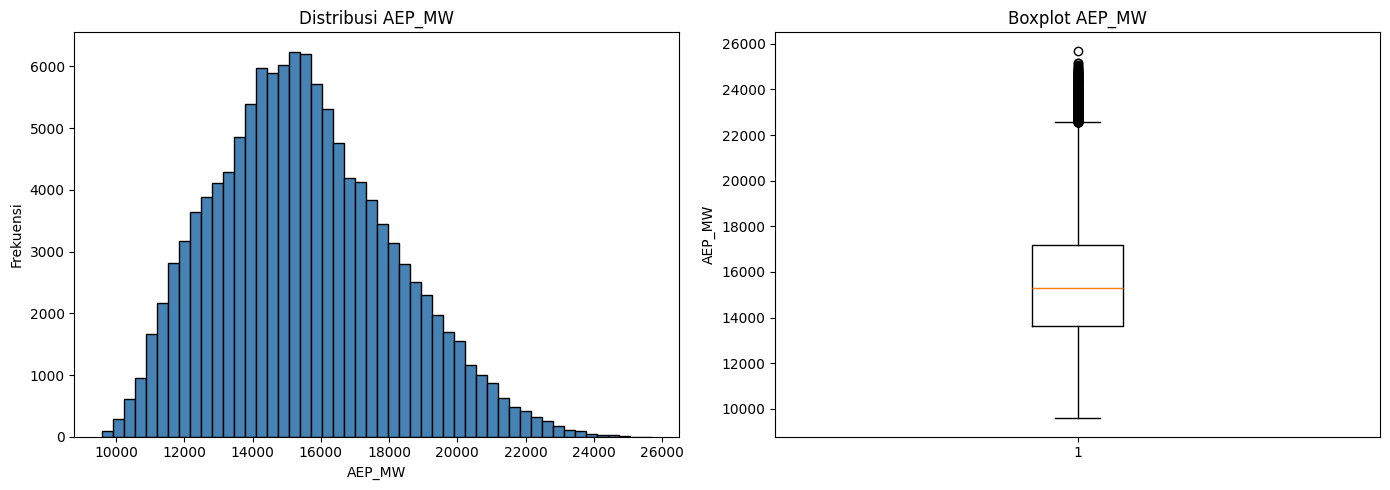

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(energy_data['AEP_MW'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi AEP_MW')
axes[0].set_xlabel('AEP_MW')
axes[0].set_ylabel('Frekuensi')

# boxplot
axes[1].boxplot(energy_data['AEP_MW'])
axes[1].set_title('Boxplot AEP_MW')
axes[1].set_ylabel('AEP_MW')

plt.tight_layout()
plt.show()

###Insight Distribusi AEP_MW
Histogram:

Distribusi mendekati normal bentuknya seperti lonceng
Puncak di sekitar 14.000-16.000 MW ini range konsumsi paling umum
Sedikit skewed ke kanan ada beberapa jam dengan konsumsi sangat tinggi

Boxplot:

Median sekitar 15.000 MW
Ada beberapa outlier di atas (titik bulat di atas sekitar 24.000 MW) ini kemungkinan peak hours ekstrem di musim panas/dingin
Range data cukup lebar dari sekitar 9.500 sampai sekitar25.700 MW



##3.2 Trend Analysis

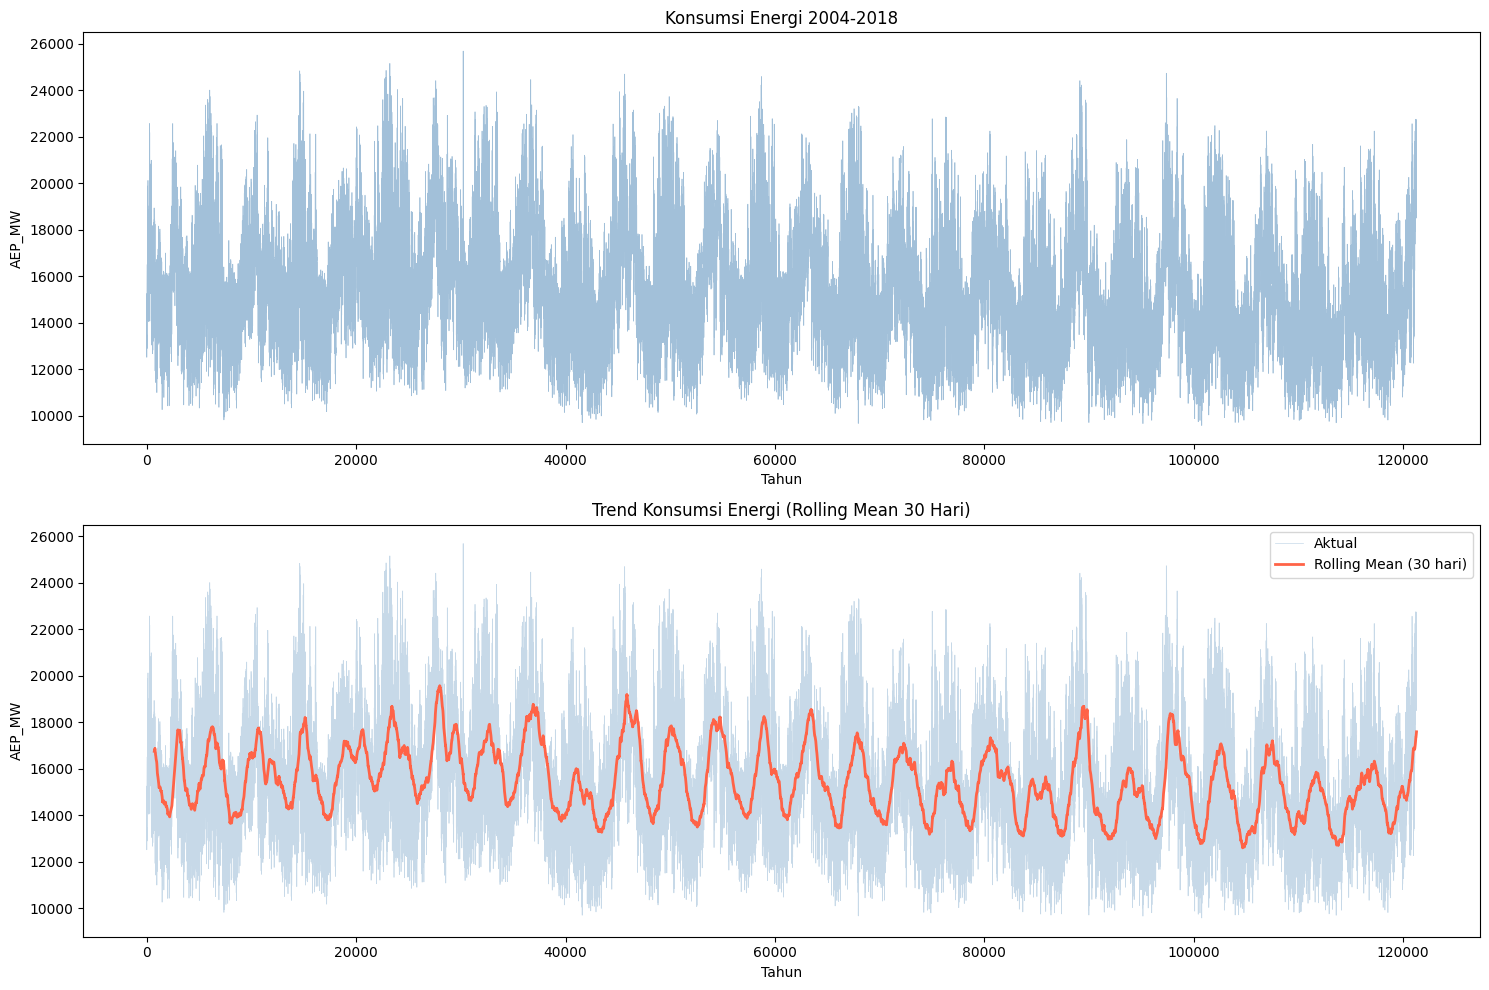

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# plot keseluruhan
axes[0].plot(energy_data.index, energy_data['AEP_MW'],
             color='steelblue', alpha=0.5, linewidth=0.5)
axes[0].set_title('Konsumsi Energi 2004-2018')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('AEP_MW')

# rolling mean 30 hari untuk lihat tren
rolling_mean = energy_data['AEP_MW'].rolling(window=720).mean()
axes[1].plot(energy_data.index, energy_data['AEP_MW'],
             color='steelblue', alpha=0.3, linewidth=0.5, label='Aktual')
axes[1].plot(energy_data.index, rolling_mean,
             color='tomato', linewidth=2, label='Rolling Mean (30 hari)')
axes[1].set_title('Trend Konsumsi Energi (Rolling Mean 30 Hari)')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('AEP_MW')
axes[1].legend()

plt.tight_layout()
plt.show()

In [71]:
#mengonversi index yang sudah ada
energy_data.index = pd.to_datetime(energy_data.index)

# Verifikasi
print(type(energy_data.index))

#mengekstrak fitur waktu
energy_data['hour'] = energy_data.index.hour
energy_data['day_of_week'] = energy_data.index.dayofweek
energy_data['month'] = energy_data.index.month
energy_data['year'] = energy_data.index.year
energy_data['year'] = energy_data.index.year

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


##3.3 Seasonality Analysis

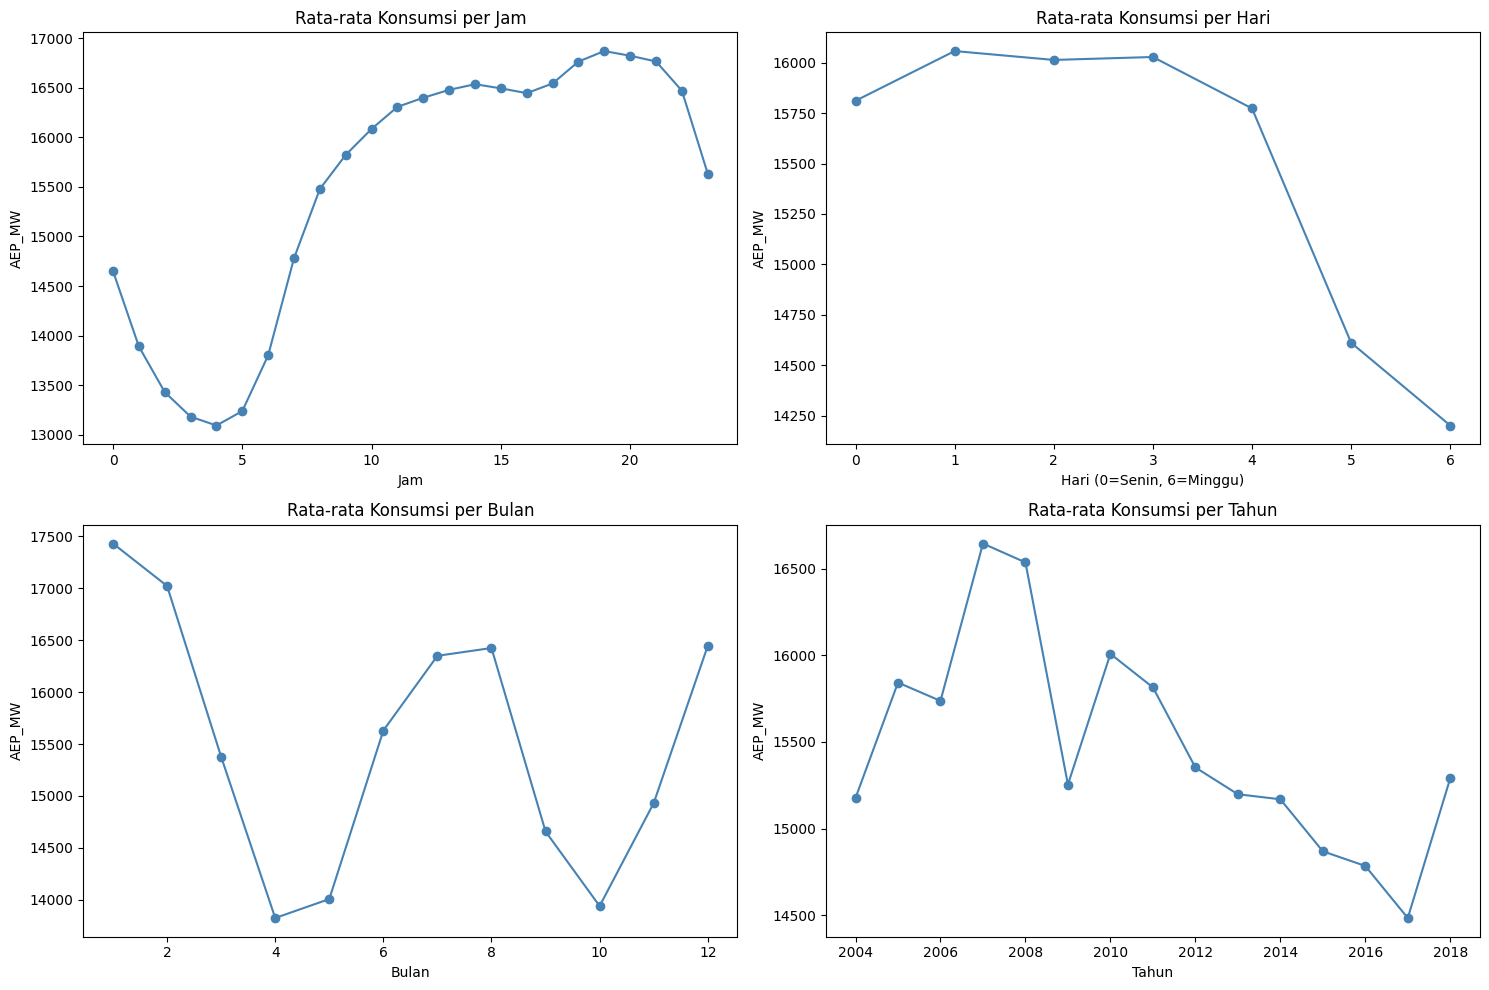

In [72]:
# mengekstrak fitur waktu
energy_data['hour'] = energy_data.index.hour
energy_data['day_of_week'] = energy_data.index.dayofweek
energy_data['month'] = energy_data.index.month
energy_data['year'] = energy_data.index.year

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# konsumsi per jam
energy_data.groupby('hour')['AEP_MW'].mean().plot(
    ax=axes[0,0], color='steelblue', marker='o')
axes[0,0].set_title('Rata-rata Konsumsi per Jam')
axes[0,0].set_xlabel('Jam')
axes[0,0].set_ylabel('AEP_MW')

# konsumsi per hari (0=Senin, 6=Minggu)
energy_data.groupby('day_of_week')['AEP_MW'].mean().plot(
    ax=axes[0,1], color='steelblue', marker='o')
axes[0,1].set_title('Rata-rata Konsumsi per Hari')
axes[0,1].set_xlabel('Hari (0=Senin, 6=Minggu)')
axes[0,1].set_ylabel('AEP_MW')

# konsumsi per bulan
energy_data.groupby('month')['AEP_MW'].mean().plot(
    ax=axes[1,0], color='steelblue', marker='o')
axes[1,0].set_title('Rata-rata Konsumsi per Bulan')
axes[1,0].set_xlabel('Bulan')
axes[1,0].set_ylabel('AEP_MW')

# konsumsi per tahun
energy_data.groupby('year')['AEP_MW'].mean().plot(
    ax=axes[1,1], color='steelblue', marker='o')
axes[1,1].set_title('Rata-rata Konsumsi per Tahun')
axes[1,1].set_xlabel('Tahun')
axes[1,1].set_ylabel('AEP_MW')

plt.tight_layout()
plt.show()

### Insight Seasonality Analysis

**Pola per Jam**: Konsumsi paling rendah ada pada dini hari sekitar jam 4-5 (sekitar 13.000 MW)
ketika orang tidur, lalu naik seiring aktivitas pagi dan puncaknya
di sore-malam jam 17-20 (sekitar 16.700 MW). Polanya sangat konsisten
dan predictable — ini yang akan jadi fitur penting di modeling nanti.

**Pola per Hari**: Hari kerja Selasa-Rabu konsumsinya paling tinggi (sekitar 16.000 MW),
sementara Minggu paling rendah (sekitar 14.200 MW). Selisihnya sekitar
1.800 MW, cukup signifikam dan masuk akal karena aktivitas
industri berhenti pada di akhir pekan.

**Pola per Bulan**: Ada dua puncak konsumsi yaitu di Januari (sekitar 17.500 MW) karena musim dingin
butuh pemanas, dan Juli-Agustus (sekitar 16.400 MW) karena musim panas
butuh AC. Paling rendah di April dan Oktober ketika cuaca sedang.

**Tren per Tahun**: Konsumsi energi cenderung turun dari 2008 ke 2017, dari sekitar 16.500 MW
ke 14.700 MW. Kemungkinan karena efisiensi energi yang makin baik
atau perubahan industri di wilayah tersebut.

#3.4 Peak Anaysis

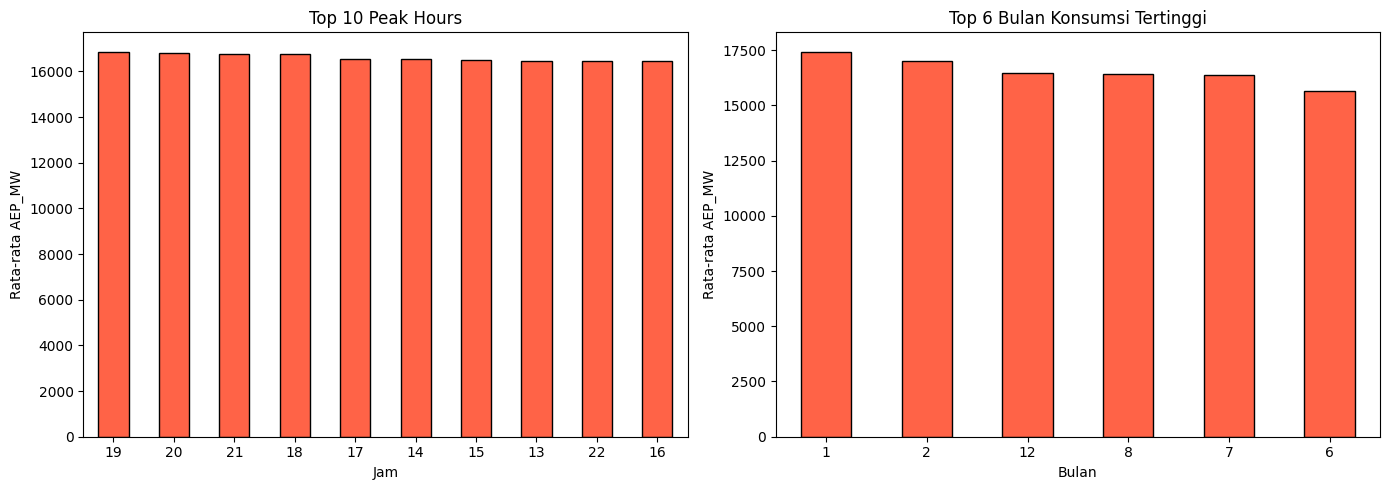

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# top 10 jam tersibuk
top_hours = energy_data.groupby('hour')['AEP_MW'].mean().sort_values(ascending=False).head(10)
top_hours.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Top 10 Peak Hours')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata AEP_MW')
axes[0].tick_params(axis='x', rotation=0)

# top bulan tersibuk
top_months = energy_data.groupby('month')['AEP_MW'].mean().sort_values(ascending=False).head(6)
top_months.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Top 6 Bulan Konsumsi Tertinggi')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Rata-rata AEP_MW')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Insight Peak Analysis

**Peak Hours**
10 jam dengan konsumsi tertinggi semuanya berada di rentang
jam 13-22, dengan puncak tertinggi di jam 19-21 (sekitar 16.600 MW).
Ini konsisten dengan pola aktivitas sore-malam dimana bila diasumsikan pada jam orang pulang kerja, beberapa aktivitas seperti menyalakan AC/pemanas, masak, dan nonton TV secara bersamaan sehingga
konsunsi melonjak.

yang menarik, jam 13-15 juga masuk top 10 yang berarti kemungkinan karena
aktivitas komersial dan industri masih penuh di siang hari.

**Peak Months**
Bulan dengan konsumsi tertingi adalah Januari dan Februari
(sekitar 17.000-17.500 MW), musim dingin paling ekstrem yang
butuh pemanas besar. Desember juga masuk top 3 karena masih
musim dingin.

Yang menarik, bulan musim panas (Juni-Agustus) juga masuk
top 6, menunjukkan bahwa penggunaan AC di musim panas hampir
menyamai kebutuhan pemanas di musim dingin.

##3.5 Correlation Analysis

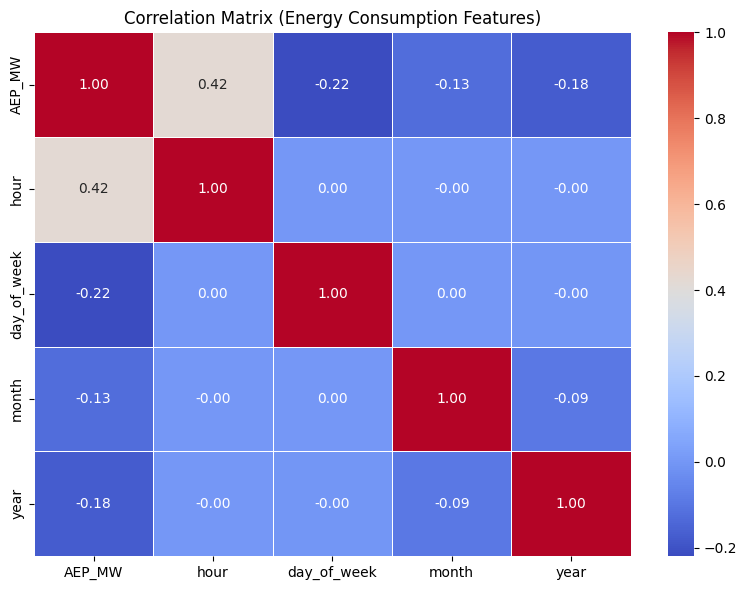

In [76]:
corr_data = energy_data[['AEP_MW', 'hour', 'day_of_week', 'month', 'year']].copy()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Matrix (Energy Consumption Features)')
plt.tight_layout()
plt.show()

###Insight Konsumsi Energi AEP 2004–2018
###Pola Musiman
Setiap tahun selalu ada dua puncak konsumsi musim panas dan musim dingin yang didorong oleh penggunaan AC dan pemanas. Pola ini sangat konsisten selama 14 tahun, sehingga fitur month dan encoding siklikalmya akan cukup krusial dalam modeling.
Fluktuasi Harian
Fluktuasi dalam satu hari bisa mencapai ~10.000 MW, yang menunjukkan bahwa waktu dalam sehari sangat menentukan besarnya konsumsi. Hal ini selaras dengan korelasi jour sebesar 0.42 pada correlation matrix sebelumnya.
Tren Jangka Panjang
Konsumsi energi secara keseluruan menunjukkan tren menurun sejak 2010, kemungkinan akibat peningkatan efisiensi energi dan berkembangnya energi terbarukan. Ada lonjakan di sekitar 2008–2010 yang diduga berkaitan dengan krisis ekonomi global saat itu.

#3. Features Engineering

##3.1 Cek Kondisi Data

In [77]:
print(type(energy_data.index))
print(energy_data.columns.tolist())
print(energy_data.shape)
print(energy_data.head(3))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
['index', 'AEP_MW', 'hour', 'day_of_week', 'month', 'year']
(121273, 6)
                     index   AEP_MW  hour  day_of_week  month  year
Datetime                                                           
2004-12-31 01:00:00      0  13478.0     1            4     12  2004
2004-12-31 02:00:00      1  12865.0     2            4     12  2004
2004-12-31 03:00:00      2  12577.0     3            4     12  2004


In [78]:
#Drop kolom index
energy_data = energy_data.drop(columns=['index'])

###3.2 Fitur Siklikal (Hour & Month)

In [81]:
import numpy as np

# Encoding siklikal
energy_data['hour_sin'] = np.sin(2 * np.pi * energy_data['hour'] / 24)
energy_data['hour_cos'] = np.cos(2 * np.pi * energy_data['hour'] / 24)

energy_data['month_sin'] = np.sin(2 * np.pi * energy_data['month'] / 12)
energy_data['month_cos'] = np.cos(2 * np.pi * energy_data['month'] / 12)

energy_data['dow_sin'] = np.sin(2 * np.pi * energy_data['day_of_week'] / 7)
energy_data['dow_cos'] = np.cos(2 * np.pi * energy_data['day_of_week'] / 7)

print(energy_data[['hour_sin', 'hour_cos', 'month_sin', 'month_cos']].head(3))

                     hour_sin  hour_cos     month_sin  month_cos
Datetime                                                        
2004-12-31 01:00:00  0.258819  0.965926 -2.449294e-16        1.0
2004-12-31 02:00:00  0.500000  0.866025 -2.449294e-16        1.0
2004-12-31 03:00:00  0.707107  0.707107 -2.449294e-16        1.0


###3.3 Fitur Kalender

In [83]:
energy_data['is_weekend'] = (energy_data['day_of_week'] >= 5).astype(int)
energy_data['quarter'] = energy_data.index.quarter
energy_data['is_peak_hour'] = energy_data['hour'].isin([8,9,10,11,17,18,19,20]).astype(int)

print(energy_data[['is_weekend', 'quarter', 'is_peak_hour']].head(3))

                     is_weekend  quarter  is_peak_hour
Datetime                                              
2004-12-31 01:00:00           0        4             0
2004-12-31 02:00:00           0        4             0
2004-12-31 03:00:00           0        4             0


###3.4 Lag Features

In [84]:
energy_data['lag_1']   = energy_data['AEP_MW'].shift(1)
energy_data['lag_2']   = energy_data['AEP_MW'].shift(2)
energy_data['lag_24']  = energy_data['AEP_MW'].shift(24)
energy_data['lag_48']  = energy_data['AEP_MW'].shift(48)
energy_data['lag_168'] = energy_data['AEP_MW'].shift(168)

print(energy_data[['AEP_MW', 'lag_1', 'lag_24', 'lag_168']].head(10))

                      AEP_MW    lag_1  lag_24  lag_168
Datetime                                              
2004-12-31 01:00:00  13478.0      NaN     NaN      NaN
2004-12-31 02:00:00  12865.0  13478.0     NaN      NaN
2004-12-31 03:00:00  12577.0  12865.0     NaN      NaN
2004-12-31 04:00:00  12517.0  12577.0     NaN      NaN
2004-12-31 05:00:00  12670.0  12517.0     NaN      NaN
2004-12-31 06:00:00  13038.0  12670.0     NaN      NaN
2004-12-31 07:00:00  13692.0  13038.0     NaN      NaN
2004-12-31 08:00:00  14297.0  13692.0     NaN      NaN
2004-12-31 09:00:00  14719.0  14297.0     NaN      NaN
2004-12-31 10:00:00  14941.0  14719.0     NaN      NaN


###3.5 Rolling Statistics

In [85]:
energy_data['rolling_mean_24']  = energy_data['AEP_MW'].rolling(window=24).mean()
energy_data['rolling_std_24']   = energy_data['AEP_MW'].rolling(window=24).std()
energy_data['rolling_mean_168'] = energy_data['AEP_MW'].rolling(window=168).mean()

print(energy_data[['AEP_MW', 'rolling_mean_24', 'rolling_mean_168']].head(200).tail(3))

                      AEP_MW  rolling_mean_24  rolling_mean_168
Datetime                                                       
2004-12-23 06:00:00  14394.0     16316.000000      16718.607143
2004-12-23 07:00:00  15034.0     16277.125000      16718.416667
2004-12-23 08:00:00  15783.0     16241.916667      16718.488095


###3.6 Drop NaN & Verifikasi Akhir

In [86]:
energy_data = energy_data.dropna()

print(f"Shape setelah dropna: {energy_data.shape}")
print(f"Missing values: {energy_data.isnull().sum().sum()}")
print(f"\nSemua fitur:")
print(energy_data.columns.tolist())

Shape setelah dropna: (121105, 22)
Missing values: 0

Semua fitur:
['AEP_MW', 'hour', 'day_of_week', 'month', 'year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'quarter', 'is_peak_hour', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168']


#4. Train Test Split

##4.1 Fitur dan Target

In [87]:
features = [
    'hour', 'day_of_week', 'month', 'year',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'quarter', 'is_peak_hour',
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168'
]

X = energy_data[features]
y = energy_data['AEP_MW']

print(f"Total data: {len(X)}")

Total data: 121105


##4.2 Split Berdasarkan Waktu

In [88]:
split_date = '2017-01-01'

X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

print(f"Train: {X_train.shape} | {X_train.index.min()} sampai {X_train.index.max()}")
print(f"Test : {X_test.shape}  | {X_test.index.min()} sampai {X_test.index.max()}")

Train: (107209, 21) | 2004-10-01 01:00:00 sampai 2016-12-31 23:00:00
Test : (13896, 21)  | 2017-01-01 00:00:00 sampai 2018-08-03 00:00:00


##4.3 Verifikasi Proporsi

In [89]:
total = len(X)
print(f"Train: {len(X_train)/total*100:.1f}%")
print(f"Test : {len(X_test)/total*100:.1f}%")

Train: 88.5%
Test : 11.5%
